# S&P 500 GARCH Analyse

Dieses Notebook dokumentiert die Analyse der Volatilität des S&P 500 Index unter Verwendung eines GARCH(1,1)-Modells. 
Es visualisiert die tatsächlichen Renditen im Vergleich zur vom Modell prognostizierten Volatilität.

## 1. Importe und Konfiguration
Hier werden die notwendigen Bibliotheken geladen und der Analysezeitraum definiert.

In [1]:
import pandas as pd
from arch import arch_model
import matplotlib.pyplot as plt
import numpy as np
import os

# Konfiguration der Zeiträume (Ersetzt command line arguments)
TRAIN_UNTIL = '2023-01-01'  # Das Modell lernt aus Daten bis zu diesem Datum
PLOT_START = '2023-01-01'   # Beginn der Visualisierung
PLOT_END = '2024-12-31'     # Ende der Visualisierung

print(f"--- Konfiguration ---")
print(f"Training bis:      {TRAIN_UNTIL}")
print(f"Darstellung von:   {PLOT_START} bis {PLOT_END}")
print(f"---------------------")

--- Konfiguration ---
Training bis:      2023-01-01
Darstellung von:   2023-01-01 bis 2024-12-31
---------------------


## 2. Daten laden und vorbereiten
Der Datensatz stammt von https://www.kaggle.com/datasets/andrewmvd/sp-500-stocks/versions/1022

Wir laden die S&P 500 Daten aus der CSV-Datei und berechnen die täglichen prozentualen Renditen.

In [2]:
# Daten laden
try:
    # Pfad ggf. anpassen, wenn das Notebook nicht im 'analysis' Ordner ausgeführt wird
    data_path = '../data/sp500_index.csv'
    if not os.path.exists(data_path):
        data_path = 'data/sp500_index.csv' # Fallback für Ausführung aus Root
        
    df = pd.read_csv(data_path, index_col='Date', parse_dates=True)
    print("Daten erfolgreich geladen.")
except FileNotFoundError:
    print(f"Fehler: Datei nicht gefunden unter {data_path}")

# Renditen berechnen (Prozentuale Änderung)
returns = df['S&P500'].pct_change().dropna() * 100

Daten erfolgreich geladen.


## 3. Modellierung (GARCH 1,1)
Ein GARCH(1,1) Modell wird an die Renditen angepasst. Dabei nutzen wir alle Daten bis zum `TRAIN_UNTIL` Zeitpunkt für das Fitting.

In [3]:
train_end_date = pd.Timestamp(TRAIN_UNTIL)

print("Trainiere GARCH(1,1) Modell...")
# 'vol="Garch"' spezifiziert das Standard-GARCH Modell
model = arch_model(returns, vol='Garch', p=1, q=1)

# Fit des Modells nur bis zum Trainings-Enddatum
results = model.fit(last_obs=train_end_date, disp='off')

print(results.summary())

Trainiere GARCH(1,1) Modell...
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 S&P500   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2627.13
Distribution:                  Normal   AIC:                           5262.27
Method:            Maximum Likelihood   BIC:                           5284.71
                                        No. Observations:                 2020
Date:                Mon, Jan 05 2026   Df Residuals:                     2019
Time:                        17:53:04   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0807  1.653e-02 

## 4. Prognose und Volatilitätsberechnung
Wir erstellen eine Prognose basierend auf dem trainierten Modell für den gewünschten Zeitraum.

In [4]:
# Prognose ab dem Ende des Trainingszeitraums
forecasts = results.forecast(start=train_end_date)

# Extrahieren der Varianz und Berechnung der Volatilität (Standardabweichung)
pred_var = forecasts.variance[train_end_date:]
pred_vol = np.sqrt(pred_var)

## 5. Visualisierung
Das Ergebnis wird als Diagramm dargestellt. Es zeigt die tatsächlichen Renditen (grau) und die vom Modell geschätzte Volatilität (rot).

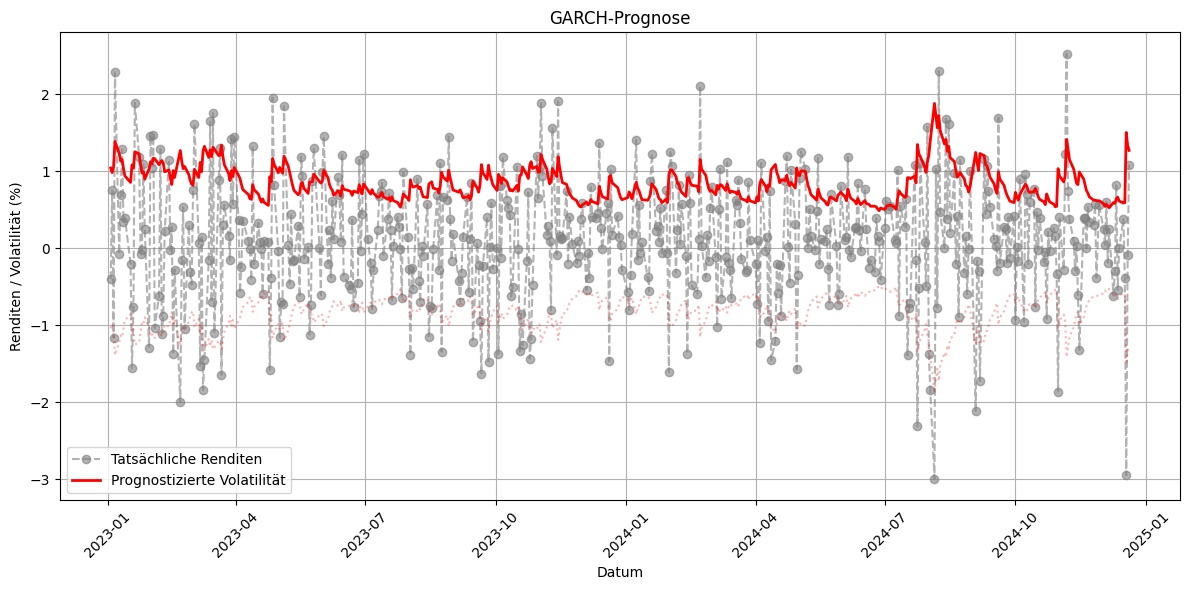

In [5]:
plot_start_date = pd.Timestamp(PLOT_START)
plot_end_date = pd.Timestamp(PLOT_END)

# Daten filtern für den Plot-Zeitraum
mask_pred = (pred_vol.index >= plot_start_date) & (pred_vol.index <= plot_end_date)
view_pred = pred_vol.loc[mask_pred]

mask_ret = (returns.index >= plot_start_date) & (returns.index <= plot_end_date)
view_returns = returns.loc[mask_ret]

# Plot erstellen
plt.figure(figsize=(12, 6))

# Tatsächliche Renditen
plt.plot(view_returns.index, view_returns, color='grey', alpha=0.6, label='Tatsächliche Renditen', marker='o', linestyle='--')

# Prognostizierte Volatilität
plt.plot(view_pred.index, view_pred['h.1'], color='red', label='Prognostizierte Volatilität', linewidth=2)

# Optional: Spiegelung für "Envelope"-Effekt (optischer Kanal)
plt.plot(view_pred.index, -view_pred['h.1'], color='red', linestyle=':', alpha=0.3)

plt.title('GARCH-Prognose')
plt.xlabel('Datum')
plt.ylabel('Renditen / Volatilität (%)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()